<a href="https://colab.research.google.com/github/202422/Startup-Operational-Status-prediction-using-Machine-learning/blob/work_branch/Data_Preprocessing/.ipynb_checkpoints/Startup_Steps_Data_Preprocessing-checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Data Preprocessing Steps:-***

In [106]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import joblib

sns.set()
warnings.filterwarnings('ignore')

In [2]:
company = pd.read_csv("companies.csv")
company

,id,Unnamed: 0.1,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,...,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at,lat,lng,ROI
0,c:1,0,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,...,2010-09-05,2013-09-18,5.0,17.0,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00,47.606209,-122.332071,15.5
1,c:10,1,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,...,NaN,NaN,NaN,6.0,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14,34.021122,-118.396467,NaN
2,c:100,2,Company,100,NaN,There,there,/company/there,games_video,acquired,...,2003-02-01,2011-09-23,4.0,12.0,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48,37.562992,-122.325525,NaN
3,c:10000,3,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,...,NaN,NaN,NaN,NaN,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18,NaN,NaN,NaN
4,c:10001,4,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,...,NaN,NaN,NaN,NaN,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196548,c:99940,196548,Company,99940,NaN,Webgility,webgility,/company/webgility,ecommerce,operating,...,2013-08-12,2013-08-12,2.0,5.0,NaN,2011-09-06 23:17:56,2013-08-13 00:39:13,37.774929,-122.419415,NaN
196549,c:9995,196549,Company,9995,NaN,FohBoh,fohboh,/company/fohboh,public_relations,operating,...,2013-05-01,2013-05-01,1.0,14.0,NaN,2008-08-24 15:46:26,2013-06-28 20:55:30,37.338208,-121.886329,NaN
196550,c:9996,196550,Company,9996,NaN,CSC,csc,/company/csc,consulting,operating,...,2012-01-01,2013-10-30,3.0,44.0,NaN,2008-08-24 15:46:58,2013-06-28 20:52:01,38.882334,-77.171091,NaN
196551,c:9997,196551,Company,9997,NaN,Top-candidate,top candidate,/company/top-candidate,search,operating,...,NaN,NaN,NaN,1.0,NaN,2008-08-24 16:00:22,2013-06-28 20:56:44,34.052234,-118.243685,NaN


In [3]:
company.head()

,id,Unnamed: 0.1,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,...,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at,lat,lng,ROI
0,c:1,0,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,...,2010-09-05,2013-09-18,5.0,17.0,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00,47.606209,-122.332071,15.5
1,c:10,1,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,...,NaN,NaN,NaN,6.0,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14,34.021122,-118.396467,NaN
2,c:100,2,Company,100,NaN,There,there,/company/there,games_video,acquired,...,2003-02-01,2011-09-23,4.0,12.0,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48,37.562992,-122.325525,NaN
3,c:10000,3,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,...,NaN,NaN,NaN,NaN,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18,NaN,NaN,NaN
4,c:10001,4,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,...,NaN,NaN,NaN,NaN,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18,NaN,NaN,NaN


In [4]:
company.describe()

,Unnamed: 0.1,entity_id,parent_id,logo_width,logo_height,investment_rounds,invested_companies,funding_rounds,funding_total_usd,milestones,relationships,lat,lng,ROI
count,196553.000000,196553.000000,0.0,110110.000000,110110.000000,2591.000000,2591.000000,31707.000000,2.787400e+04,91699.000000,129667.000000,83852.000000,83852.000000,726.000000
mean,98276.000000,153006.227333,NaN,459.132685,222.728917,2.372057,2.204940,1.659760,1.481652e+07,1.199402,2.852067,37.564512,-52.123066,45.745037
std,56740.108067,90209.250941,NaN,594.982577,333.090722,12.173510,11.436955,1.201666,6.775937e+07,0.540099,9.100309,15.477102,70.049067,572.035638
min,0.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,2.910000e+02,1.000000,1.000000,-50.942326,-159.497746,0.011111
25%,49138.000000,59850.000000,NaN,192.000000,70.000000,1.000000,1.000000,1.000000,5.000000e+05,1.000000,1.000000,34.052234,-111.940005,2.648879
50%,98276.000000,174539.000000,NaN,267.000000,105.000000,1.000000,1.000000,1.000000,2.564500e+06,1.000000,1.000000,39.768403,-77.036871,6.500497
75%,147414.000000,232655.000000,NaN,484.000000,232.000000,1.000000,1.000000,2.000000,1.100000e+07,1.000000,3.000000,45.421530,-0.127758,13.549900
max,196552.000000,286215.000000,NaN,18200.000000,9600.000000,478.000000,459.000000,15.000000,5.700000e+09,9.000000,1189.000000,77.553604,176.212549,13333.333333


In [5]:
company.columns

Index(['id', 'Unnamed: 0.1', 'entity_type', 'entity_id', 'parent_id', 'name',
       'normalized_name', 'permalink', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url',
       'logo_width', 'logo_height', 'short_description', 'description',
       'overview', 'tag_list', 'country_code', 'state_code', 'city', 'region',
       'first_investment_at', 'last_investment_at', 'investment_rounds',
       'invested_companies', 'first_funding_at', 'last_funding_at',
       'funding_rounds', 'funding_total_usd', 'first_milestone_at',
       'last_milestone_at', 'milestones', 'relationships', 'created_by',
       'created_at', 'updated_at', 'lat', 'lng', 'ROI'],
      dtype='object')

In [6]:
#Displaying the percentage of NaN values in each column
(company.isna().sum()/company.shape[0]).sort_values(ascending = False)

,0
parent_id,1.000000
ROI,0.996306
last_investment_at,0.986859
first_investment_at,0.986859
investment_rounds,0.986818
invested_companies,0.986818
closed_at,0.986670
short_description,0.963720
funding_total_usd,0.858186
last_funding_at,0.839702


## A. Data Cleaning
    1. Delete irrelevant & redundant information.
    2. Remove noise or unreliable data (missing values and outliers).
    
### 1. Delete irrelevant and redundant information
     a. Delete 'region','city','state_code' as they provide too much of granularity.
     b. Delete 'id', 'Unnamed: 0.1', 'entity_type', 'entity_id', 'parent_id', 'created_by',
       'created_at', 'updated_at' as they are redundant.
     c. Delete 'domain', 'homepage_url', 'twitter_username', 'logo_url', 'logo_width', 'logo_height',           
        'short_description', 'description', 'overview','tag_list', 'name', 'normalized_name', 'permalink',    
        'invested_companies' as they are irrelevant features.
     d. Delete duplicate values if any.
     e. Delete those which has more than 98% of null values.
     
### 2. Remove noise or unreliable data (missing values and outliers)
     a. Delete instances with missing values for 'status', 'country_code', 'category_code' and 'founded_at'.
     b. Delete outliers for 'funding_total_usd' and 'funding_rounds'.
     c. Delete contradictory (mutually opposed or inconsistent data).

#### 1.a. Delete 'region','city' and 'state_code' as they provide too much of granularity.    

In [7]:
company = company.drop(["region","city", "state_code"], axis = 1)

In [8]:
company.columns

Index(['id', 'Unnamed: 0.1', 'entity_type', 'entity_id', 'parent_id', 'name',
       'normalized_name', 'permalink', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url',
       'logo_width', 'logo_height', 'short_description', 'description',
       'overview', 'tag_list', 'country_code', 'first_investment_at',
       'last_investment_at', 'investment_rounds', 'invested_companies',
       'first_funding_at', 'last_funding_at', 'funding_rounds',
       'funding_total_usd', 'first_milestone_at', 'last_milestone_at',
       'milestones', 'relationships', 'created_by', 'created_at', 'updated_at',
       'lat', 'lng', 'ROI'],
      dtype='object')

#### 1.b. Delete 'id', 'Unnamed: 0.1', 'entity_type', 'entity_id', 'parent_id', 'created_by', 'created_at', 'updated_at' as they are redundant.

In [9]:
company = company.drop(['id', 'Unnamed: 0.1', 'entity_type', 'entity_id', 'parent_id', 'created_by', 'created_at', 'updated_at'], axis = 1)

In [10]:
company.columns

Index(['name', 'normalized_name', 'permalink', 'category_code', 'status',
       'founded_at', 'closed_at', 'domain', 'homepage_url', 'twitter_username',
       'logo_url', 'logo_width', 'logo_height', 'short_description',
       'description', 'overview', 'tag_list', 'country_code',
       'first_investment_at', 'last_investment_at', 'investment_rounds',
       'invested_companies', 'first_funding_at', 'last_funding_at',
       'funding_rounds', 'funding_total_usd', 'first_milestone_at',
       'last_milestone_at', 'milestones', 'relationships', 'lat', 'lng',
       'ROI'],
      dtype='object')

#### 1.c. Delete 'domain', 'homepage_url', 'twitter_username', 'logo_url', 'logo_width', 'logo_height',  'short_description',    'description',  'overview','tag_list', 'name', 'normalized_name', 'permalink', 'invested_companies' as they are irrelevant features.

In [11]:
company = company.drop(['domain', 'homepage_url', 'twitter_username', 'logo_url', 'logo_width', 'logo_height', 'short_description', 'description', 'overview','tag_list', 'name', 'normalized_name', 'permalink', 'invested_companies'], axis = 1)

In [12]:
company.columns

Index(['category_code', 'status', 'founded_at', 'closed_at', 'country_code',
       'first_investment_at', 'last_investment_at', 'investment_rounds',
       'first_funding_at', 'last_funding_at', 'funding_rounds',
       'funding_total_usd', 'first_milestone_at', 'last_milestone_at',
       'milestones', 'relationships', 'lat', 'lng', 'ROI'],
      dtype='object')

#### 1.d. Delete duplicate values if found any.

In [13]:
#Checking if there are duplicated values
company[company.duplicated()]

,category_code,status,founded_at,closed_at,country_code,first_investment_at,last_investment_at,investment_rounds,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,ROI
79,NaN,operating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
114,NaN,operating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,NaN,acquired,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,NaN,operating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
132,NaN,acquired,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196533,NaN,operating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196534,NaN,operating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196535,NaN,operating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196536,NaN,operating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#let's see how many duplicate values are present
np.sum( company.duplicated() == True)

np.int64(87089)

In [15]:
# Let's delete all the duplicate values
company = company.drop_duplicates()

In [16]:
# check if any are left
company[company.duplicated()]

,category_code,status,founded_at,closed_at,country_code,first_investment_at,last_investment_at,investment_rounds,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,ROI


#### 1.e. Delete those which has more than 98% of null values.

In [17]:
company

,category_code,status,founded_at,closed_at,country_code,first_investment_at,last_investment_at,investment_rounds,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,ROI
0,web,operating,2005-10-17,NaN,USA,NaN,NaN,NaN,2005-10-01,2008-05-19,3.0,39750000.0,2010-09-05,2013-09-18,5.0,17.0,47.606209,-122.332071,15.5
1,games_video,acquired,NaN,NaN,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,34.021122,-118.396467,NaN
2,games_video,acquired,NaN,NaN,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-02-01,2011-09-23,4.0,12.0,37.562992,-122.325525,NaN
3,network_hosting,operating,2008-07-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,games_video,operating,2008-07-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196548,ecommerce,operating,2007-01-01,NaN,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-08-12,2013-08-12,2.0,5.0,37.774929,-122.419415,NaN
196549,public_relations,operating,2007-11-01,NaN,USA,NaN,NaN,NaN,2008-08-25,2008-08-25,1.0,750000.0,2013-05-01,2013-05-01,1.0,14.0,37.338208,-121.886329,NaN
196550,consulting,operating,1959-01-01,NaN,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-01-01,2013-10-30,3.0,44.0,38.882334,-77.171091,NaN
196551,search,operating,2008-07-01,NaN,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,34.052234,-118.243685,NaN


In [18]:
# Since we can see only nan values so let's check how many nan values there are in each column
(company.isna().sum()/company.shape[0]).sort_values(ascending = False)

,0
ROI,0.993368
last_investment_at,0.979473
first_investment_at,0.979473
investment_rounds,0.979436
closed_at,0.976074
funding_total_usd,0.745469
last_funding_at,0.712490
first_funding_at,0.712490
funding_rounds,0.710672
last_milestone_at,0.487402


In [19]:
# # Since we can see it has more than 96% of null values, it would not make sense to impute these data. So, lets drop it.
#Type your code here!
company = company.drop(["ROI","first_investment_at","last_investment_at","investment_rounds"], axis = 1)

In [20]:
(company.isna().sum()/company.shape[0]).sort_values(ascending = False)

,0
closed_at,0.976074
funding_total_usd,0.745469
first_funding_at,0.712490
last_funding_at,0.712490
funding_rounds,0.710672
last_milestone_at,0.487402
first_milestone_at,0.487402
milestones,0.487402
relationships,0.314286
lat,0.259108


#### 2.a. Delete instances with missing values for 'status', 'country_code', 'category_code' and 'founded_at'.
    (Since these are the type of data where adding value via imputation will create wrong pattern only)

In [21]:
company = company.dropna( subset = ['status','country_code','category_code','founded_at'])

In [22]:
# Since we can see only nan values so let's check how many nan values there are in each column
(company.isna().sum()/company.shape[0]).sort_values(ascending = False)

,0
closed_at,0.973877
funding_total_usd,0.678116
first_funding_at,0.642227
last_funding_at,0.642227
funding_rounds,0.640025
last_milestone_at,0.445718
first_milestone_at,0.445718
milestones,0.445718
relationships,0.240466
lat,0.037336


In [23]:
company.shape

(63585, 15)

In [24]:
# Since we can see only nan values so let's check how much of rows has nan values.
company.isna().any(axis=1).sum()

np.int64(62944)

In [25]:
company

,category_code,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng
0,web,operating,2005-10-17,NaN,USA,2005-10-01,2008-05-19,3.0,39750000.0,2010-09-05,2013-09-18,5.0,17.0,47.606209,-122.332071
5,advertising,operating,2007-06-27,NaN,MAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107
6,cleantech,operating,2008-08-20,NaN,IND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219
12,advertising,operating,2008-08-01,NaN,USA,NaN,NaN,NaN,NaN,2008-08-22,2008-08-22,1.0,2.0,35.686975,-105.937799
13,web,acquired,2007-10-01,NaN,USA,2008-02-26,2008-02-26,1.0,5000000.0,2008-05-01,2012-09-13,3.0,14.0,37.386052,-122.083851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196548,ecommerce,operating,2007-01-01,NaN,USA,NaN,NaN,NaN,NaN,2013-08-12,2013-08-12,2.0,5.0,37.774929,-122.419415
196549,public_relations,operating,2007-11-01,NaN,USA,2008-08-25,2008-08-25,1.0,750000.0,2013-05-01,2013-05-01,1.0,14.0,37.338208,-121.886329
196550,consulting,operating,1959-01-01,NaN,USA,NaN,NaN,NaN,NaN,2012-01-01,2013-10-30,3.0,44.0,38.882334,-77.171091
196551,search,operating,2008-07-01,NaN,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,34.052234,-118.243685


#### 2.b. Delete outliers for 'funding_total_usd' and 'funding_rounds'.

<Axes: xlabel='funding_total_usd'>

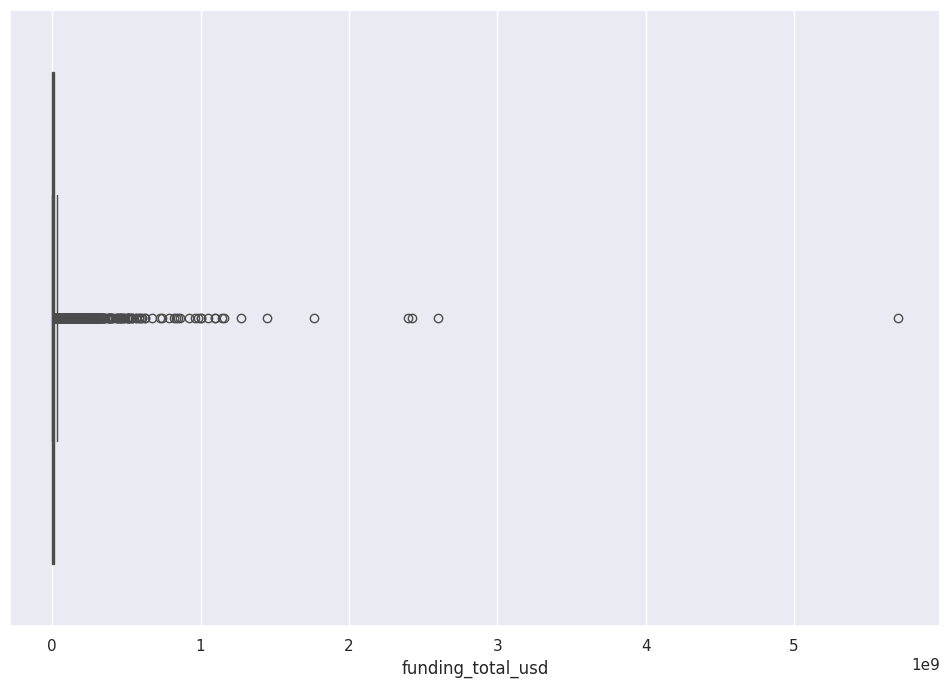

In [26]:
plt.figure(figsize = (12,8))
sns.boxplot(x = company["funding_total_usd"])

<Axes: xlabel='funding_rounds'>

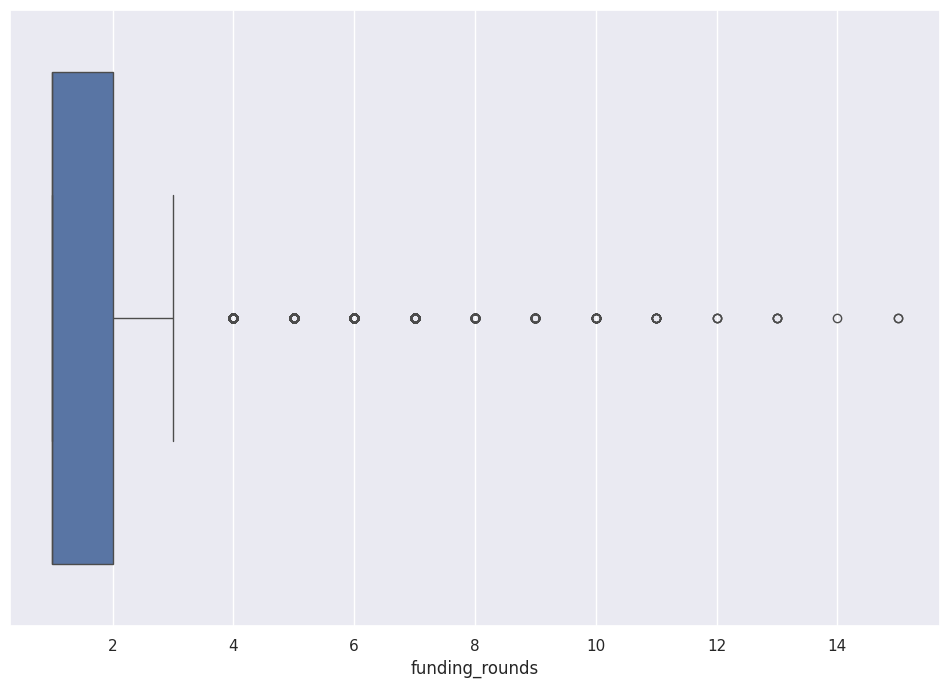

In [27]:
plt.figure(figsize = (12,8))
sns.boxplot(x = company["funding_rounds"])

### Summary:
If you can see the outlier in both 'funding_total_usd' and 'funding_rounds'. So, let's find them and drop it.

    1. Find the IQR (Interquartile Range)
    2. Find the upper and lower limit
    3. Find outliers
    4. Drop them
    5. Compare the plots after trimming


#### 2.b.1. Find the IQR

In [28]:
# For funding_total_usd
Q1_funding_tot = company["funding_total_usd"].quantile(0.25)
Q3_funding_tot = company["funding_total_usd"].quantile(0.75)
IQR_funding_tot = Q3_funding_tot - Q1_funding_tot

# For funding_rounds
Q1_funding_rnd = company["funding_rounds"].quantile(0.25)
Q3_funding_rnd = company["funding_rounds"].quantile(0.75)
IQR_funding_rnd = Q3_funding_rnd - Q1_funding_rnd

In [29]:
print("Q1_funding_tot: {}\nQ3_funding_tot: {}\nIQR_funding_tot: {}\n\nQ1_funding_rnd: {}\nQ3_funding_rnd: {}\nIQR_funding_rnd: {}".format(Q1_funding_tot,Q3_funding_tot,IQR_funding_tot,Q1_funding_rnd,Q3_funding_rnd,IQR_funding_rnd))

Q1_funding_tot: 511038.0
Q3_funding_tot: 12000000.0
IQR_funding_tot: 11488962.0

Q1_funding_rnd: 1.0
Q3_funding_rnd: 2.0
IQR_funding_rnd: 1.0


#### 2.b.1. Find the Upper and Lower limit

In [30]:
# For funding_total_usd
low_lim_funding_tot = Q1_funding_tot - 1.5*IQR_funding_tot
up_lim_funding_tot = Q3_funding_tot + 1.5*IQR_funding_tot

# For funding_rounds
low_lim_funding_rnd = Q1_funding_rnd - 1.5*IQR_funding_rnd
up_lim_funding_rnd = Q3_funding_rnd + 1.5*IQR_funding_rnd

In [31]:
print("Funding total\nLower limit: {}\nUpper Limit: {}\n\nFunding rounds\nLower limit: {}\nUpper Limit: {}".format(low_lim_funding_tot,up_lim_funding_tot,low_lim_funding_rnd,up_lim_funding_rnd))

Funding total
Lower limit: -16722405.0
Upper Limit: 29233443.0

Funding rounds
Lower limit: -0.5
Upper Limit: 3.5


#### 2.b.1.  Find outliers

In [32]:
# For funding_total_usd
outliers_f_tot = company[(company["funding_total_usd"]<low_lim_funding_tot) | (company["funding_total_usd"]>up_lim_funding_tot)]

# For funding_rounds
outliers_f_rnd = company[(company["funding_rounds"]<low_lim_funding_rnd) | (company["funding_rounds"]>up_lim_funding_rnd)]

In [33]:
outliers_f_tot

,category_code,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng
0,web,operating,2005-10-17,NaN,USA,2005-10-01,2008-05-19,3.0,39750000.0,2010-09-05,2013-09-18,5.0,17.0,47.606209,-122.332071
19,health,operating,2007-10-01,NaN,USA,2008-10-10,2013-08-13,5.0,68069200.0,NaN,NaN,NaN,14.0,37.774929,-122.419415
24,analytics,operating,2006-01-01,NaN,USA,2008-08-25,2013-03-28,3.0,33000000.0,2010-05-18,2013-03-01,3.0,19.0,37.774929,-122.419415
66,mobile,acquired,2005-01-01,NaN,USA,2005-03-01,2012-07-02,7.0,121500000.0,2012-01-19,2013-08-13,3.0,45.0,42.360082,-71.058880
80,games_video,operating,2003-04-01,NaN,USA,2006-08-28,2012-01-01,3.0,95097200.0,2009-11-12,2013-01-01,3.0,28.0,37.774929,-122.419415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196290,mobile,operating,2001-01-01,NaN,DEU,2002-02-13,2009-12-15,5.0,40673570.0,2002-02-01,2002-02-01,1.0,11.0,48.027728,11.586918
196298,hardware,operating,1995-01-01,NaN,USA,2008-08-19,2010-12-21,3.0,146000000.0,2009-05-01,2010-07-15,3.0,23.0,37.485215,-122.236355
196415,security,operating,1997-01-01,NaN,USA,2005-02-07,2005-02-07,1.0,108000000.0,2011-07-01,2013-02-21,3.0,17.0,39.920541,-105.086650
196496,games_video,acquired,2004-01-01,NaN,CHN,2005-01-01,2011-02-04,4.0,286500000.0,2009-05-01,2011-02-04,2.0,3.0,31.230390,121.473702


In [34]:
outliers_f_rnd

,category_code,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng
19,health,operating,2007-10-01,NaN,USA,2008-10-10,2013-08-13,5.0,68069200.0,NaN,NaN,NaN,14.0,37.774929,-122.419415
66,mobile,acquired,2005-01-01,NaN,USA,2005-03-01,2012-07-02,7.0,121500000.0,2012-01-19,2013-08-13,3.0,45.0,42.360082,-71.058880
134,ecommerce,operating,2006-01-01,NaN,USA,2007-01-01,2011-07-21,5.0,46400000.0,2011-08-01,2012-08-31,2.0,20.0,42.360082,-71.058880
224,advertising,operating,2005-01-01,NaN,USA,2006-03-13,2012-06-05,5.0,37570663.0,2005-09-01,2011-08-03,2.0,4.0,38.040584,-84.503716
243,enterprise,acquired,2008-09-10,NaN,USA,2009-01-19,2012-02-29,5.0,142000000.0,2012-01-12,2013-11-18,3.0,38.0,37.774929,-122.419415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196293,security,acquired,1999-01-01,NaN,USA,2005-02-25,2010-10-11,4.0,24500000.0,2008-01-01,2011-01-20,2.0,2.0,43.071755,-70.762553
196356,travel,operating,2010-01-01,NaN,USA,2008-05-01,2011-12-20,4.0,3265000.0,2009-08-07,2012-01-01,4.0,9.0,39.739236,-104.990251
196360,security,operating,2003-03-01,NaN,USA,2003-01-01,2013-09-10,7.0,28200000.0,2011-03-21,2012-01-01,3.0,20.0,38.984652,-77.094709
196496,games_video,acquired,2004-01-01,NaN,CHN,2005-01-01,2011-02-04,4.0,286500000.0,2009-05-01,2011-02-04,2.0,3.0,31.230390,121.473702


#### 2.b.1. Drop the outliers

In [35]:
# Combine the indices of outliers for both columns
combined_outliers = outliers_f_tot.index.union(outliers_f_rnd.index)
combined_outliers

Index([     0,     19,     24,     66,     80,    134,    155,    184,    224,
          243,
       ...
       196256, 196289, 196290, 196293, 196298, 196356, 196360, 196415, 196496,
       196522],
      dtype='int64', length=3598)

In [36]:
# Drop the combined outliers from the company DataFrame
company = company.drop(index = combined_outliers, axis = 0)

In [37]:
company

,category_code,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng
5,advertising,operating,2007-06-27,NaN,MAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107
6,cleantech,operating,2008-08-20,NaN,IND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219
12,advertising,operating,2008-08-01,NaN,USA,NaN,NaN,NaN,NaN,2008-08-22,2008-08-22,1.0,2.0,35.686975,-105.937799
13,web,acquired,2007-10-01,NaN,USA,2008-02-26,2008-02-26,1.0,5000000.0,2008-05-01,2012-09-13,3.0,14.0,37.386052,-122.083851
15,games_video,operating,2008-01-01,NaN,USA,NaN,NaN,NaN,NaN,2008-01-01,2008-01-01,1.0,3.0,33.078655,-116.601964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196548,ecommerce,operating,2007-01-01,NaN,USA,NaN,NaN,NaN,NaN,2013-08-12,2013-08-12,2.0,5.0,37.774929,-122.419415
196549,public_relations,operating,2007-11-01,NaN,USA,2008-08-25,2008-08-25,1.0,750000.0,2013-05-01,2013-05-01,1.0,14.0,37.338208,-121.886329
196550,consulting,operating,1959-01-01,NaN,USA,NaN,NaN,NaN,NaN,2012-01-01,2013-10-30,3.0,44.0,38.882334,-77.171091
196551,search,operating,2008-07-01,NaN,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,34.052234,-118.243685


<Axes: xlabel='funding_rounds'>

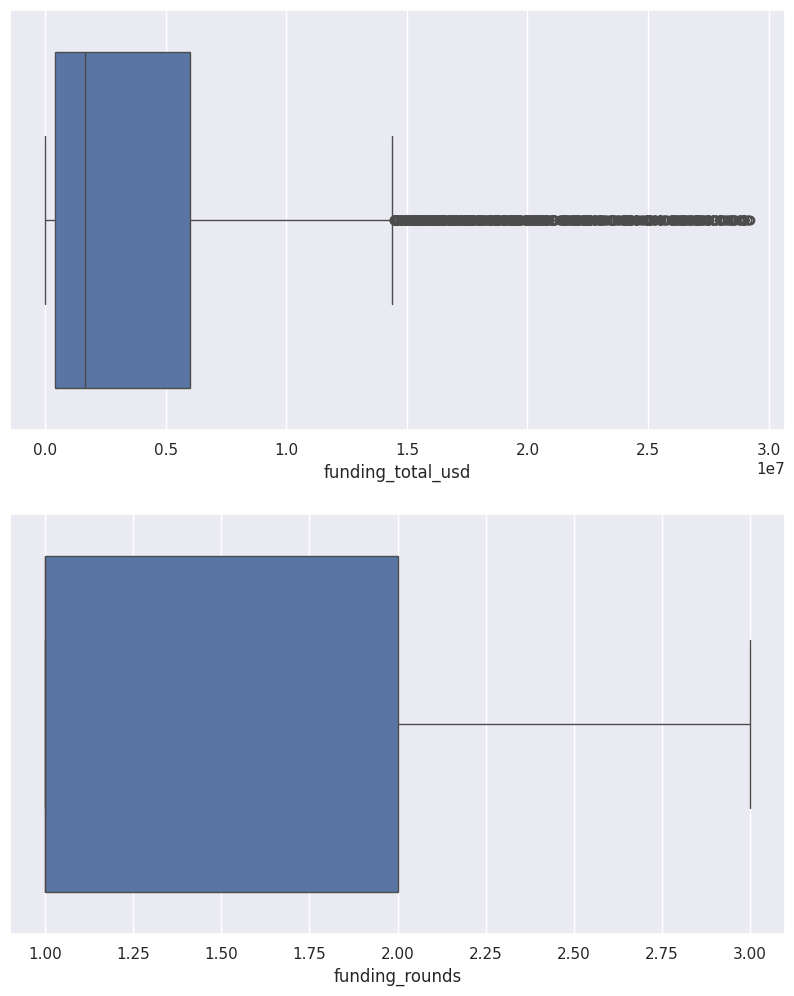

In [38]:
plt.figure(figsize = (10,12))
plt.subplot(2,1,1)
sns.boxplot(x = company["funding_total_usd"])
plt.subplot(2,1,2)
sns.boxplot(x = company["funding_rounds"])

#### 2.c. Delete contradictory (mutually opposed or inconsistent data).


In [39]:
company[company["status"] == "closed"]

,category_code,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng
72,web,closed,2006-09-01,2010-05-22,USA,2008-01-01,2008-01-01,1.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN
120,web,closed,2007-01-01,2012-07-24,USA,2007-01-01,2007-01-01,1.0,100000.0,2009-01-16,2009-01-16,1.0,1.0,37.386052,-122.083851
133,games_video,closed,2006-08-01,2010-02-23,DEU,2008-04-08,2008-04-08,1.0,5000000.0,2008-03-10,2012-05-10,5.0,3.0,51.826685,6.587620
136,software,closed,2008-06-01,2010-07-01,USA,NaN,NaN,NaN,NaN,2013-10-06,2013-10-06,1.0,2.0,32.715738,-117.161084
151,web,closed,2006-11-30,2013-09-01,FIN,2012-01-19,2012-01-19,1.0,1613875.0,NaN,NaN,NaN,3.0,60.169856,24.938379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196315,games_video,closed,2000-06-01,2007-06-02,RUS,NaN,NaN,NaN,NaN,2008-09-29,2013-03-06,2.0,NaN,55.755826,37.617300
196348,web,closed,2006-04-05,2009-01-01,SGP,2006-03-01,2007-02-01,2.0,370000.0,NaN,NaN,NaN,5.0,1.352083,103.819836
196482,web,closed,2002-06-09,2011-11-23,USA,2006-12-15,2006-12-15,1.0,400000.0,NaN,NaN,NaN,1.0,39.739236,-104.990251
196526,mobile,closed,2008-05-22,2012-08-15,USA,2008-05-18,2008-05-18,1.0,130000.0,2008-08-03,2009-09-01,2.0,3.0,37.774929,-122.419415


In [40]:
company[company["closed_at"].notna()]

,category_code,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng
72,web,closed,2006-09-01,2010-05-22,USA,2008-01-01,2008-01-01,1.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN
120,web,closed,2007-01-01,2012-07-24,USA,2007-01-01,2007-01-01,1.0,100000.0,2009-01-16,2009-01-16,1.0,1.0,37.386052,-122.083851
133,games_video,closed,2006-08-01,2010-02-23,DEU,2008-04-08,2008-04-08,1.0,5000000.0,2008-03-10,2012-05-10,5.0,3.0,51.826685,6.587620
136,software,closed,2008-06-01,2010-07-01,USA,NaN,NaN,NaN,NaN,2013-10-06,2013-10-06,1.0,2.0,32.715738,-117.161084
151,web,closed,2006-11-30,2013-09-01,FIN,2012-01-19,2012-01-19,1.0,1613875.0,NaN,NaN,NaN,3.0,60.169856,24.938379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196315,games_video,closed,2000-06-01,2007-06-02,RUS,NaN,NaN,NaN,NaN,2008-09-29,2013-03-06,2.0,NaN,55.755826,37.617300
196348,web,closed,2006-04-05,2009-01-01,SGP,2006-03-01,2007-02-01,2.0,370000.0,NaN,NaN,NaN,5.0,1.352083,103.819836
196482,web,closed,2002-06-09,2011-11-23,USA,2006-12-15,2006-12-15,1.0,400000.0,NaN,NaN,NaN,1.0,39.739236,-104.990251
196526,mobile,closed,2008-05-22,2012-08-15,USA,2008-05-18,2008-05-18,1.0,130000.0,2008-08-03,2009-09-01,2.0,3.0,37.774929,-122.419415


<Axes: >

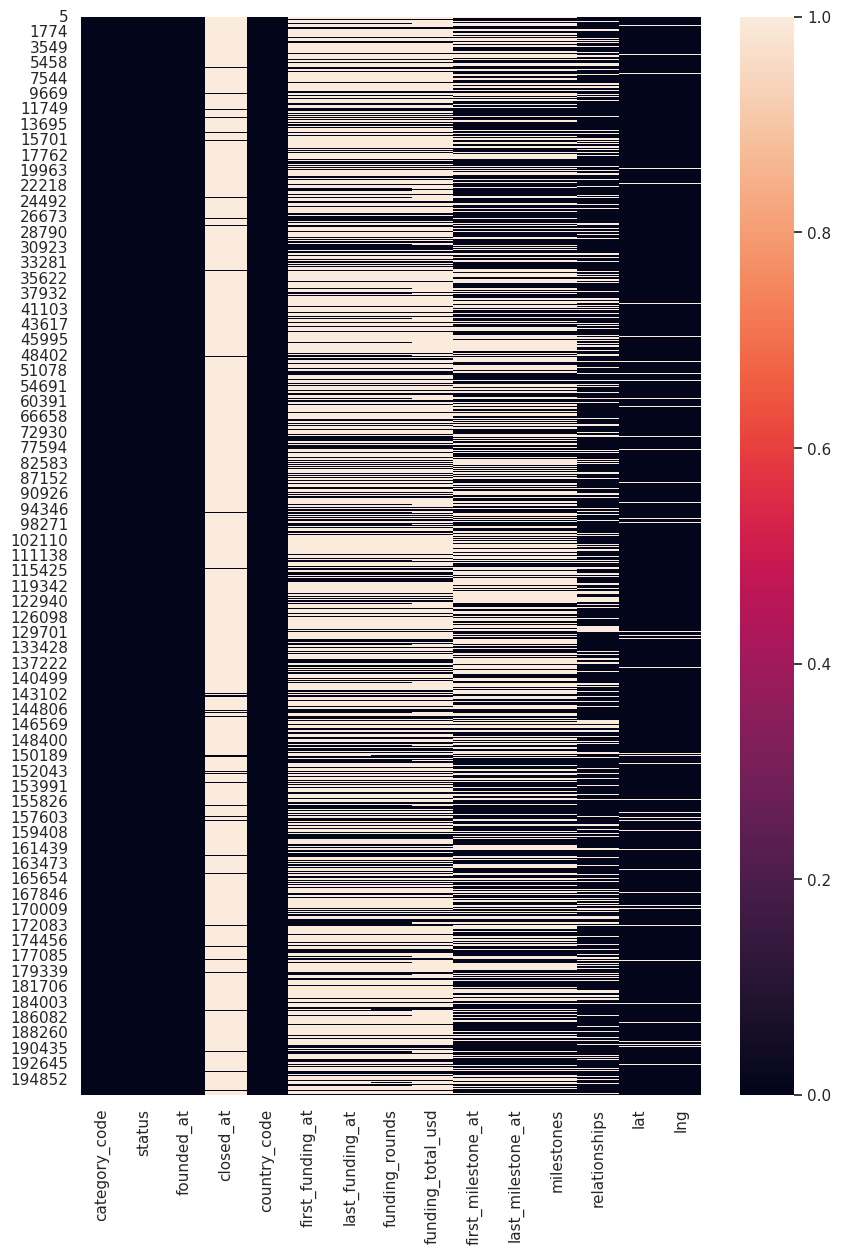

In [41]:
plt.figure(figsize = (10,14))
sns.heatmap(company.isna())

In [42]:
# As lat, lng and country_code are related, we will remove NaN values in lat and lng
(company.isna().sum()/company.shape[0]).sort_values(ascending = False)

,0
closed_at,0.974261
funding_total_usd,0.718606
first_funding_at,0.680747
last_funding_at,0.680747
funding_rounds,0.678414
last_milestone_at,0.459500
first_milestone_at,0.459500
milestones,0.459500
relationships,0.251988
lat,0.038825


In [43]:
company = company.dropna(subset = ["lat","lng"], axis = 0)

In [44]:
(company.isna().sum()/company.shape[0]).sort_values(ascending = False)

,0
closed_at,0.974557
funding_total_usd,0.715061
first_funding_at,0.677165
last_funding_at,0.677165
funding_rounds,0.674928
last_milestone_at,0.455756
first_milestone_at,0.455756
milestones,0.455756
relationships,0.247962
status,0.000000


# B. Date Transformation
    It can be divided into two successive phases.
   ## 1. Changes in original data
        a. Convert founded_at, closed_at, first_funded_at, last_funding_at, first_milestone_at ,
           last_milestone_at to years.
        b. Generalize the categorical data i.e. category_code and country_code.
   ## 2. Create new variables
        a. Create new feature isClosed from closed_at and status.
        b. Create new feature 'active_days'

#### 1.a. Convert founded_at, closed_at, first_funded_at, last_funding_at, first_milestone_at , last_milestone_at to years.

In [45]:
# For founded_at
company["founded_at"] = pd.to_datetime(company["founded_at"]).dt.year

# closed_at
company["closed_at"] = pd.to_datetime(company["closed_at"]).dt.year

# first_funding_at
company["first_funding_at"] = pd.to_datetime(company["first_funding_at"]).dt.year

# last_funding_at
company["last_funding_at"] = pd.to_datetime(company["last_funding_at"]).dt.year

# first_milestone_at
company["first_milestone_at"] = pd.to_datetime(company["first_milestone_at"]).dt.year

# last_milestone_at
company["last_milestone_at"] = pd.to_datetime(company["last_milestone_at"]).dt.year

company

,category_code,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng
5,advertising,operating,2007,NaN,MAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107
6,cleantech,operating,2008,NaN,IND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219
12,advertising,operating,2008,NaN,USA,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,2.0,35.686975,-105.937799
13,web,acquired,2007,NaN,USA,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,14.0,37.386052,-122.083851
15,games_video,operating,2008,NaN,USA,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,3.0,33.078655,-116.601964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196548,ecommerce,operating,2007,NaN,USA,NaN,NaN,NaN,NaN,2013.0,2013.0,2.0,5.0,37.774929,-122.419415
196549,public_relations,operating,2007,NaN,USA,2008.0,2008.0,1.0,750000.0,2013.0,2013.0,1.0,14.0,37.338208,-121.886329
196550,consulting,operating,1959,NaN,USA,NaN,NaN,NaN,NaN,2012.0,2013.0,3.0,44.0,38.882334,-77.171091
196551,search,operating,2008,NaN,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,34.052234,-118.243685


 #### 1.b. Generalize the categorical data i.e. category_code and  country_code

In [46]:
# 1. category_code
company[["category_code"]]

,category_code
5,advertising
6,cleantech
12,advertising
13,web
15,games_video
...,...
196548,ecommerce
196549,public_relations
196550,consulting
196551,search


In [47]:
# Since there are 42 categories, one-hot encoding will create many columns
# Let's check the frequency of values in ascending order,
# keep the top 10 values, and categorize the remaining ones as 'other'

(company["category_code"].value_counts()).sort_values(ascending = False)

,count
category_code,
software,10635
web,7316
ecommerce,4614
other,4529
mobile,3540
advertising,3443
consulting,2697
games_video,2632
enterprise,2396


In [48]:
# Lets keep the category the same if it falls within the top 10; otherwise, let's replace it with 'other'.
keep_cat = ["software","web","ecommerce","mobile","advertising","consulting","games_video","enterprise","biotech","public_relations"]
company["category_code"] = company["category_code"].apply(lambda x: x if x in keep_cat else "other")

In [49]:
(company["category_code"].value_counts()).sort_values(ascending = False)

,count
category_code,
other,16927
software,10635
web,7316
ecommerce,4614
mobile,3540
advertising,3443
consulting,2697
games_video,2632
enterprise,2396


In [50]:
# One-hot encoding to category_code
ohe_tr = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False).set_output(transform = 'pandas')
ohe_tr_df = ohe_tr.fit_transform(company[["category_code"]])

In [51]:
ohe_tr_df

,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
196548,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
196550,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [52]:
# Concatenate category with company dataset
company = pd.concat([company,ohe_tr_df], axis = 1, ignore_index = False)
company.head()

,category_code,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,...,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web
5,advertising,operating,2007,NaN,MAR,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,other,operating,2008,NaN,IND,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12,advertising,operating,2008,NaN,USA,NaN,NaN,NaN,NaN,2008.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,web,acquired,2007,NaN,USA,2008.0,2008.0,1.0,5000000.0,2008.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15,games_video,operating,2008,NaN,USA,NaN,NaN,NaN,NaN,2008.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [53]:
# Since, We've added the encoded category_columns, let's delete original category_code
company = company.drop("category_code", axis = 1)

In [54]:
company.head(5)

,status,founded_at,closed_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,...,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web
5,operating,2007,NaN,MAR,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,operating,2008,NaN,IND,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12,operating,2008,NaN,USA,NaN,NaN,NaN,NaN,2008.0,2008.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,acquired,2007,NaN,USA,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15,operating,2008,NaN,USA,NaN,NaN,NaN,NaN,2008.0,2008.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Let's encode 'country' column now.

In [55]:
# 1. country_code
company[["country_code"]]

,country_code
5,MAR
6,IND
12,USA
13,USA
15,USA
...,...
196548,USA
196549,USA
196550,USA
196551,USA


In [56]:
# Since there are 161 categories, one-hot encoding which is going to create a lot of columns so
# Lets Check the frequency of value in ascending order and keep the first 10 values and name
# remaining ones as 'other'.

((company["country_code"].value_counts()).sort_values(ascending = False)).head(15)


,count
country_code,
USA,32893
GBR,4686
IND,2866
CAN,2528
DEU,1328
FRA,1175
AUS,956
ESP,855
ISR,694


In [57]:
# Lets keep the country the same if it falls within the top 10; otherwise let's replace it with other.
keep_val = ["USA","GBR","IND","CAN","DEU","FRA","AUS","ESP","ISR","NLD" ]
company["country_code"] = company["country_code"].apply(lambda x: x if x in keep_val else "other")


In [58]:
((company["country_code"].value_counts()).sort_values(ascending = False)).head(15)

,count
country_code,
USA,32893
other,9051
GBR,4686
IND,2866
CAN,2528
DEU,1328
FRA,1175
AUS,956
ESP,855


In [59]:
# One-hot encoding to category_code
ohe_tr2 = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False).set_output(transform = 'pandas')
ohe_tr2_df = ohe_tr2.fit_transform(company[["country_code"]])

In [60]:
ohe_tr2_df

,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
196548,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
196549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
196550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
196551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [61]:
# Concatenate category with company dataset
company = pd.concat([company,ohe_tr2_df], axis = 1, ignore_index = False)

In [62]:
# Since, We've added the encoded country_code , let's delete original category_code
company.drop("country_code", axis = 1, inplace = True)

In [63]:
company.head()

,status,founded_at,closed_at,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,...,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
5,operating,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,operating,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12,operating,2008,NaN,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13,acquired,2007,NaN,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15,operating,2008,NaN,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 2. Create new variables¶
    a. Create new feature isClosed from closed_at and status.
    b. Create new feature 'active_days'

#### 2.a. Create new feature isClosed from closed_at and status.
     - if the value in status is 'operating' or 'ipo', Let's put 0.
     - Where as if the value is 'acquired' or 'closed', let's put 1.

In [64]:
val_1 = ["operating", "ipo"]

def new_feat(value):
    if value in val_1:
        return 0
    else:
        return 1

In [65]:
company["isClosed"] = company["status"].apply(new_feat)

In [66]:
company[["status","isClosed"]].head(5)

,status,isClosed
5,operating,0
6,operating,0
12,operating,0
13,acquired,1
15,operating,0


#### 2.b. Create active_days
     i. Replacing values:
         - if the value is 'acquired' or 'closed' and the corresponding value in closed_at is NaN, let's put the value in last_milestone_at + 1 and then put the mode of closed_at corresponding to 'acquired' in  NaN value.
         -Where as if the value in status is 'operating' or 'ipo' in closed_at, Let's put 2021.
         
     ii. Subtract founded date from closed date, and calculate age in days (After calculating active days,
         check contradictory issues we didn't check it before).
     iii. Then, delete the closed_at column.

In [67]:
company["status"].value_counts()

,count
status,
operating,52381
acquired,3399
closed,1443
ipo,435


In [68]:
company["closed_at"].value_counts()

,count
closed_at,
2012.0,478
2013.0,371
2011.0,253
2010.0,172
2009.0,110
2008.0,57
2007.0,12
2006.0,5
2005.0,3


In [69]:
# Let's display rows with "acquired" and not nan values in respectively status and closed_at
company[(company["closed_at"].notna()) & (company["status"] == "acquired")]

,status,founded_at,closed_at,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,...,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other,isClosed
2234,acquired,2006,2012.0,NaN,NaN,NaN,NaN,2006.0,2012.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
2712,acquired,2005,2008.0,2006.0,2006.0,1.0,3700000.0,2007.0,2007.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3373,acquired,2003,2009.0,2006.0,2007.0,2.0,11200000.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3486,acquired,2003,2013.0,NaN,NaN,NaN,NaN,2006.0,2013.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
7492,acquired,2011,2013.0,2011.0,2011.0,1.0,NaN,2011.0,2011.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
14095,acquired,2008,2009.0,NaN,NaN,NaN,NaN,2010.0,2010.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
14254,acquired,2011,2013.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
17139,acquired,2006,2010.0,2007.0,2007.0,1.0,3000000.0,2008.0,2010.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
43277,acquired,2002,2012.0,2009.0,2009.0,1.0,150000.0,2010.0,2010.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
57996,acquired,2000,2009.0,2007.0,2007.0,1.0,16980999.0,2005.0,2005.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1


In [70]:
company.columns

Index(['status', 'founded_at', 'closed_at', 'first_funding_at',
       'last_funding_at', 'funding_rounds', 'funding_total_usd',
       'first_milestone_at', 'last_milestone_at', 'milestones',
       'relationships', 'lat', 'lng', 'category_code_advertising',
       'category_code_biotech', 'category_code_consulting',
       'category_code_ecommerce', 'category_code_enterprise',
       'category_code_games_video', 'category_code_mobile',
       'category_code_other', 'category_code_public_relations',
       'category_code_software', 'category_code_web', 'country_code_AUS',
       'country_code_CAN', 'country_code_DEU', 'country_code_ESP',
       'country_code_FRA', 'country_code_GBR', 'country_code_IND',
       'country_code_ISR', 'country_code_NLD', 'country_code_USA',
       'country_code_other', 'isClosed'],
      dtype='object')

In [71]:
pd.set_option("display.max_columns",None)
company.head(20)

,status,founded_at,closed_at,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other,isClosed
5,operating,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
6,operating,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
12,operating,2008,NaN,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,2.0,35.686975,-105.937799,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
13,acquired,2007,NaN,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,14.0,37.386052,-122.083851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
15,operating,2008,NaN,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,3.0,33.078655,-116.601964,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
18,acquired,2008,NaN,2008.0,2008.0,1.0,NaN,1995.0,2012.0,4.0,9.0,37.441883,-122.143019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
20,operating,2003,NaN,2011.0,2012.0,3.0,10125293.0,2010.0,2010.0,1.0,6.0,30.267153,-97.743061,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
22,operating,2011,NaN,NaN,NaN,NaN,NaN,2011.0,2011.0,1.0,2.0,49.050438,-122.304470,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
25,operating,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.774929,-122.419415,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
26,operating,2003,NaN,2003.0,2003.0,1.0,250000.0,2007.0,2007.0,1.0,2.0,-27.469771,153.025124,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


<Axes: >

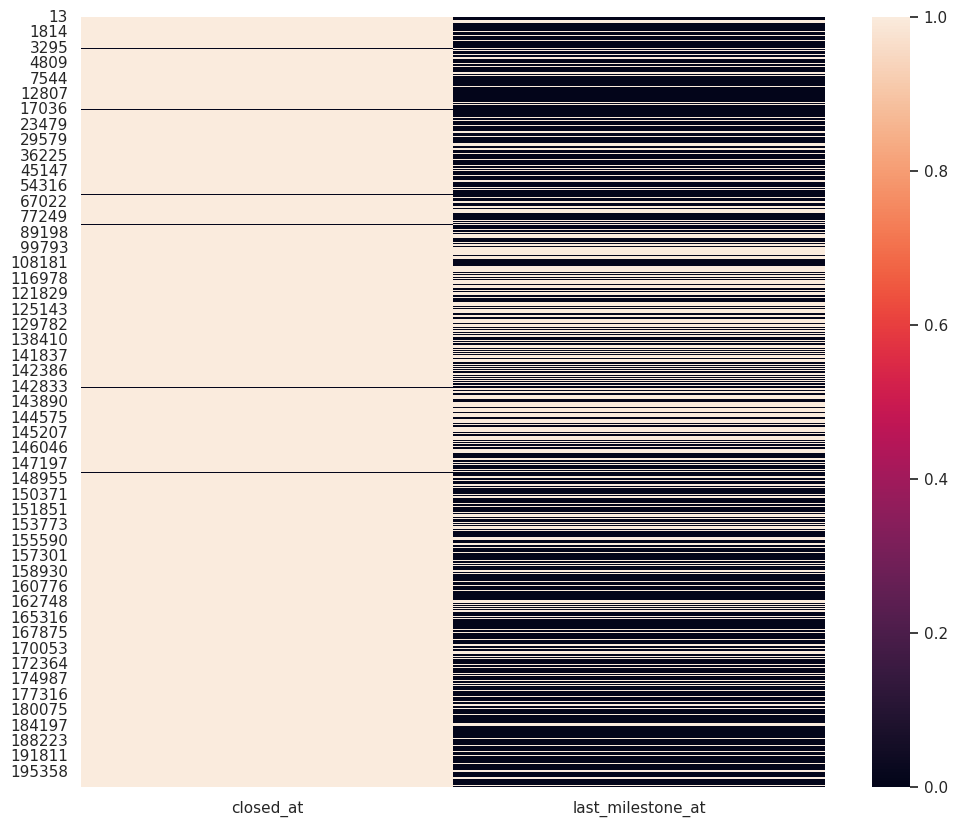

In [72]:
# Let's display heatmap of nan and not nan values in closed_at and last_milestone_at especially
# rows with "acquired" value in status
plt.figure(figsize = (12,10))
sns.heatmap((company.loc[company["status"] == "acquired", ["closed_at", "last_milestone_at"]]).isna())

##### 2.b.i  Replacing the values in closed_at column
     - if the value is 'acquired' or 'closed' and the corresponding value in closed_at is NaN, let's put the value in last_milestone_at + 1 and then put the mode of closed_at corresponding to 'acquired' in  NaN value.
     -Where as if the value in status is 'operating' or 'ipo' in closed_at, Let's put 2021.

In [73]:
# Retrieving rows' index with status = acquired
acquired_index = company[company["status"] == "acquired"].index
acquired_index

Index([    13,     18,     63,    152,    170,    177,    181,    193,    221,
          236,
       ...
       196331, 196338, 196380, 196420, 196434, 196443, 196461, 196519, 196524,
       196541],
      dtype='int64', length=3399)

In [74]:
# Replacing NaN values in 'closed_at' with the corresponding value in 'last_milestone_at' + 1
# Replacing values in 'closed_at' that are lower than the corresponding value in 'last_milestone_at' with
# the value in 'last_milestone_at' + 1
for ind in acquired_index:
    if pd.isna(company.at[ind,"closed_at"]) & pd.notna(company.at[ind,"last_milestone_at"]):
        company.at[ind,"closed_at"] = company.at[ind,"last_milestone_at"] + 1
    elif pd.isna(company.at[ind,"closed_at"]) & pd.notna(company.at[ind,"last_milestone_at"]) & (company.at[ind,"closed_at"] < company.at[ind,"last_milestone_at"]):
        company.at[ind,"closed_at"] = company.at[ind,"last_milestone_at"] + 1

<Axes: >

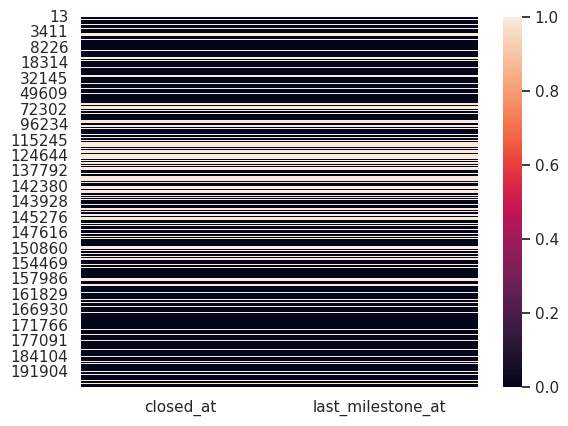

In [75]:
# Let's display heatmap of nan and not nan values in closed_at and last_milestone_at especially
# rows with "acquired" value in status
sns.heatmap((company.loc[acquired_index,["closed_at", "last_milestone_at"]]).isna())

In [76]:
# Displaying the percentage of remaining NaN values in "closed_at" column with corresponding status = "acquired"
((company.loc[acquired_index,["closed_at"]]).isna().sum())/(company.loc[acquired_index,["closed_at"]]).shape[0]

,0
closed_at,0.364225


In [77]:
# Retrieving mode value of "closed_at" with coresponding value in status = "acquired"
mode_acquired = company.loc[acquired_index, "closed_at"].mode()[0]
mode_acquired

np.float64(2014.0)

In [78]:
# Filling the missing values with mode in "closed_at" with coresponding value in status = "acquired"
company.loc[acquired_index,"closed_at"] = company.loc[acquired_index,"closed_at"].fillna(value = mode_acquired)

In [79]:
company.loc[acquired_index,"closed_at"].isna().sum()

np.int64(0)

In [80]:
# fetching rows' index with corresponding value in status = "closed"
closed_index = company[company["status"] == "closed"].index
closed_index

Index([   120,    133,    136,    151,    213,    216,    240,    287,    317,
          370,
       ...
       196172, 196205, 196240, 196257, 196304, 196315, 196348, 196482, 196526,
       196540],
      dtype='int64', length=1443)

In [81]:
# Checking the number of NaN values in "closed_at" with corresponding value in status = "closed"
company.loc[closed_index,"closed_at"].isna().sum()

np.int64(0)

In [82]:
for ind in closed_index:
    if pd.isna(company.at[ind,"closed_at"]) & pd.notna(company.at[ind,"last_milestone_at"]) & (company.at[ind,"closed_at"] < company.at[ind,"last_milestone_at"]):
        company.at[ind,"closed_at"] = company.at[ind,"last_milestone_at"] + 1

In [83]:
# Checking the percentage of NaN values in "closed_at" with corresponding value in status = "operating" or "ipo"
(company.loc[((company["status"] == "operating") | (company["status"] == "ipo")), "closed_at"].isna().sum())/(company.loc[((company["status"] == "operating") | (company["status"] == "ipo")), "closed_at"]).shape[0]

np.float64(1.0)

In [84]:
# Retrieving rows' index that are status = "operating" or "ipo"
op_ipo_index = company[(company["status"] == "operating") | (company["status"] == "ipo")].index

In [85]:
# Filling with 2021, closed_at column that are corresponding value in status = "operating" or "ipo"
for ind in op_ipo_index:
    company.at[ind,"closed_at"] = 2021

In [86]:
# Checking the percentage of NaN values in "closed_at" with corresponding value in status = "operating" or "ipo"
(company.loc[op_ipo_index, "closed_at"].isna().sum())/(company.loc[((company["status"] == "operating") | (company["status"] == "ipo")), "closed_at"]).shape[0]

np.float64(0.0)

In [87]:
# Checking the percentage of NaN values in "closed_at" with corresponding value in status = "closed" or "acquired"
(company.loc[((company["status"] == "closed") | (company["status"] == "acquired")), "closed_at"].isna().sum())/(company.loc[((company["status"] == "closed") | (company["status"] == "acquired")), "closed_at"]).shape[0]

np.float64(0.0)

In [88]:
# Checking the percentage of NaN values in "closed_at"
pd.isna(company["closed_at"]).sum()

np.int64(0)

In [89]:
company.head(20)

,status,founded_at,closed_at,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other,isClosed
5,operating,2007,2021.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
6,operating,2008,2021.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
12,operating,2008,2021.0,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,2.0,35.686975,-105.937799,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
13,acquired,2007,2013.0,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,14.0,37.386052,-122.083851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
15,operating,2008,2021.0,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,3.0,33.078655,-116.601964,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
18,acquired,2008,2013.0,2008.0,2008.0,1.0,NaN,1995.0,2012.0,4.0,9.0,37.441883,-122.143019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
20,operating,2003,2021.0,2011.0,2012.0,3.0,10125293.0,2010.0,2010.0,1.0,6.0,30.267153,-97.743061,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
22,operating,2011,2021.0,NaN,NaN,NaN,NaN,2011.0,2011.0,1.0,2.0,49.050438,-122.304470,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
25,operating,2011,2021.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.774929,-122.419415,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
26,operating,2003,2021.0,2003.0,2003.0,1.0,250000.0,2007.0,2007.0,1.0,2.0,-27.469771,153.025124,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


##### 2.b.ii Subtract founded date from closed date, and calculate age in days (After calculating active days, check contradictory issues we didn't check it before.)

In [91]:
# converting columns to datetime type
company["closed_at"] = pd.to_datetime(company["closed_at"], format = '%Y')
company["founded_at"] = pd.to_datetime(company["founded_at"], format = '%Y')

In [92]:
company

,status,founded_at,closed_at,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other,isClosed
5,operating,2007-01-01,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
6,operating,2008-01-01,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
12,operating,2008-01-01,2021-01-01,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,2.0,35.686975,-105.937799,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
13,acquired,2007-01-01,2013-01-01,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,14.0,37.386052,-122.083851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
15,operating,2008-01-01,2021-01-01,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,3.0,33.078655,-116.601964,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196548,operating,2007-01-01,2021-01-01,NaN,NaN,NaN,NaN,2013.0,2013.0,2.0,5.0,37.774929,-122.419415,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
196549,operating,2007-01-01,2021-01-01,2008.0,2008.0,1.0,750000.0,2013.0,2013.0,1.0,14.0,37.338208,-121.886329,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
196550,operating,1959-01-01,2021-01-01,NaN,NaN,NaN,NaN,2012.0,2013.0,3.0,44.0,38.882334,-77.171091,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
196551,operating,2008-01-01,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,34.052234,-118.243685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [93]:
# inserting new column "active_day"
company.insert(3,"active_days",(company["closed_at"]-company["founded_at"]).dt.days)

In [94]:
company.head()

,status,founded_at,closed_at,active_days,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other,isClosed
5,operating,2007-01-01,2021-01-01,5114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
6,operating,2008-01-01,2021-01-01,4749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
12,operating,2008-01-01,2021-01-01,4749,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,2.0,35.686975,-105.937799,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
13,acquired,2007-01-01,2013-01-01,2192,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,14.0,37.386052,-122.083851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
15,operating,2008-01-01,2021-01-01,4749,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,3.0,33.078655,-116.601964,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [95]:
company["closed_at"] = company["closed_at"].dt.year
company["founded_at"] = company["founded_at"].dt.year

#### 2.b.iii. Then, delete the closed_at column.

In [96]:
company.drop("closed_at", axis = 1, inplace = True)

In [97]:
company.head()

,status,founded_at,active_days,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other,isClosed
5,operating,2007,5114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
6,operating,2008,4749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
12,operating,2008,4749,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,2.0,35.686975,-105.937799,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
13,acquired,2007,2192,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,14.0,37.386052,-122.083851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
15,operating,2008,4749,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,3.0,33.078655,-116.601964,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


### Let's work on target variabe now.

In [98]:
# Let's encode status column
ohe_tr_target = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False).set_output(transform = 'pandas')
ohe_tr_target_df = ohe_tr_target.fit_transform(company[["status"]])
ohe_tr_target_df

,status_acquired,status_closed,status_ipo,status_operating
5,0.0,0.0,0.0,1.0
6,0.0,0.0,0.0,1.0
12,0.0,0.0,0.0,1.0
13,1.0,0.0,0.0,0.0
15,0.0,0.0,0.0,1.0
...,...,...,...,...
196548,0.0,0.0,0.0,1.0
196549,0.0,0.0,0.0,1.0
196550,0.0,0.0,0.0,1.0
196551,0.0,0.0,0.0,1.0


In [99]:
# concatenating encoded column to original dataframe
company = pd.concat([ohe_tr_target_df,company], axis = 1, ignore_index = False)
company.head()

,status_acquired,status_closed,status_ipo,status_operating,status,founded_at,active_days,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other,isClosed
5,0.0,0.0,0.0,1.0,operating,2007,5114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
6,0.0,0.0,0.0,1.0,operating,2008,4749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
12,0.0,0.0,0.0,1.0,operating,2008,4749,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,2.0,35.686975,-105.937799,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
13,1.0,0.0,0.0,0.0,acquired,2007,2192,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,14.0,37.386052,-122.083851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
15,0.0,0.0,0.0,1.0,operating,2008,4749,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,3.0,33.078655,-116.601964,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [100]:
# Droping the old "status" column
company.drop("status", axis = 1, inplace = True)

In [101]:
company.head()

,status_acquired,status_closed,status_ipo,status_operating,founded_at,active_days,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other,isClosed
5,0.0,0.0,0.0,1.0,2007,5114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.427755,-9.598107,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
6,0.0,0.0,0.0,1.0,2008,4749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.307159,73.181219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
12,0.0,0.0,0.0,1.0,2008,4749,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,2.0,35.686975,-105.937799,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
13,1.0,0.0,0.0,0.0,2007,2192,2008.0,2008.0,1.0,5000000.0,2008.0,2012.0,3.0,14.0,37.386052,-122.083851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
15,0.0,0.0,0.0,1.0,2008,4749,NaN,NaN,NaN,NaN,2008.0,2008.0,1.0,3.0,33.078655,-116.601964,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


### Remove the null values with the mean value in 'Numerical Data'

In [102]:
# checking the percentage of null values in each column
(company.isna().sum()/company.shape[0]).sort_values(ascending = False)

,0
funding_total_usd,0.715061
last_funding_at,0.677165
first_funding_at,0.677165
funding_rounds,0.674928
first_milestone_at,0.455756
milestones,0.455756
last_milestone_at,0.455756
relationships,0.247962
founded_at,0.000000
active_days,0.000000


In [103]:
# filling missing value with mean in numerical column
num_feat_miss = ["funding_total_usd","first_funding_at","last_funding_at","funding_rounds","last_milestone_at","first_milestone_at","milestones","relationships"]

for col in num_feat_miss:
    mean_val = round(company[col].mean())
    company[col] = company[col].fillna(value = mean_val)


In [104]:
# Final null check on data
(company.isna().sum()/company.shape[0]).sort_values(ascending = False)

,0
status_acquired,0.0
status_closed,0.0
status_ipo,0.0
status_operating,0.0
founded_at,0.0
active_days,0.0
first_funding_at,0.0
last_funding_at,0.0
funding_rounds,0.0
funding_total_usd,0.0


In [108]:
joblib.dump(ohe_tr, "Encoder_Category.pkl")
joblib.dump(ohe_tr2, "Encoder_Country.pkl")
joblib.dump(ohe_tr_target, "Encoder_Status.pkl")

['Encoder_Status.pkl']

In [105]:
#Finally Save cleaned Data.
company.to_csv("company_cleaned_df.csv", index = False)